In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl
import arviz as az
import palettable 

In [4]:
with open('results/4084.KRASG13D.pkl', 'rb') as buff:
    idata = pkl.load(buff)

In [5]:
with open('results/4295.JAK2R683S.rec.pkl', 'rb') as buff:
    idata_s = pkl.load(buff)
with open('results/4295.JAK2R683G.rec.pkl', 'rb') as buff:
    idata_g = pkl.load(buff)

In [6]:
ball_pal = {
    'JAK2_R683G' : '#e6ab02',
    'JAK2_R683S' : '#707abe',
}

array([[<Axes: title={'center': 'fitness'}>,
        <Axes: title={'center': 'fitness'}, xlabel='Rank (all chains)', ylabel='Chain'>],
       [<Axes: title={'center': 'aoo'}>,
        <Axes: title={'center': 'aoo'}, xlabel='Rank (all chains)', ylabel='Chain'>]],
      dtype=object)

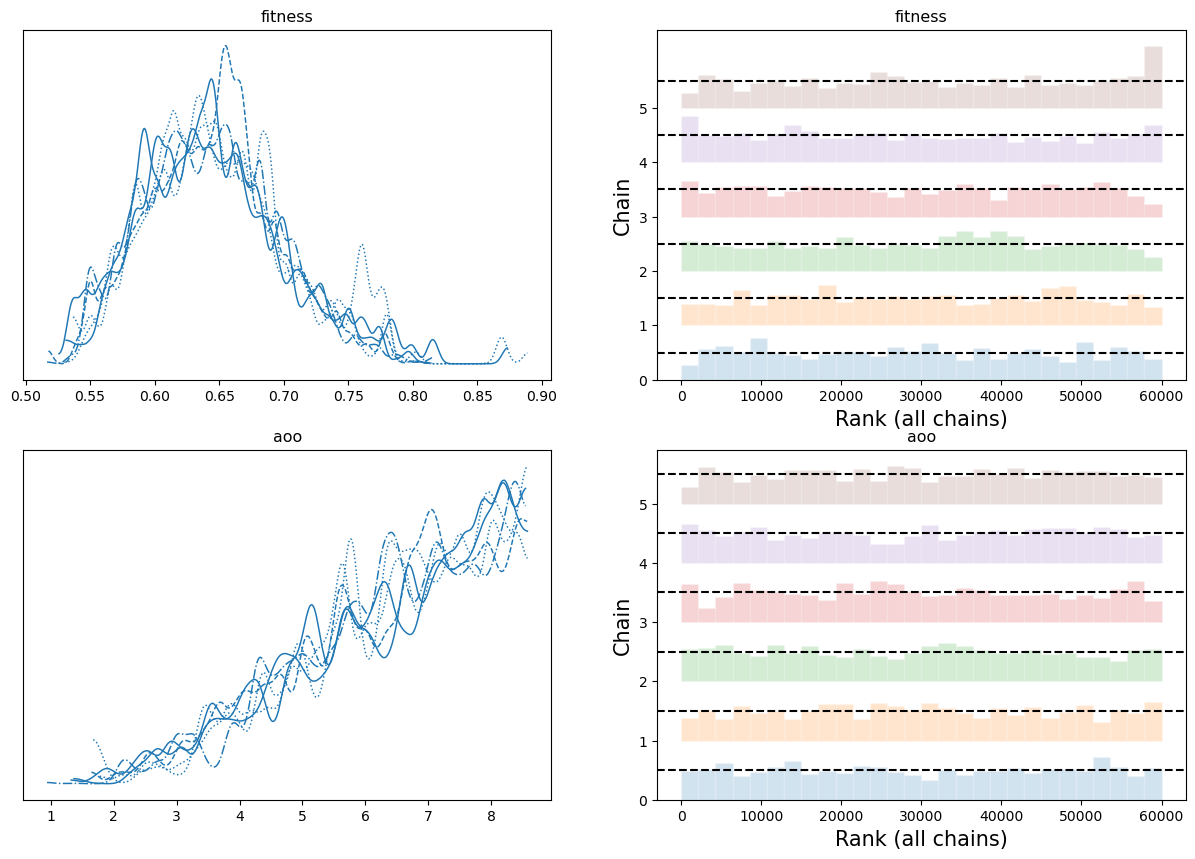

In [7]:
az.plot_trace(idata, kind="rank_bars", figsize=(15, 10))

array([<Axes: title={'center': 'fitness'}>,
       <Axes: title={'center': 'aoo'}>], dtype=object)

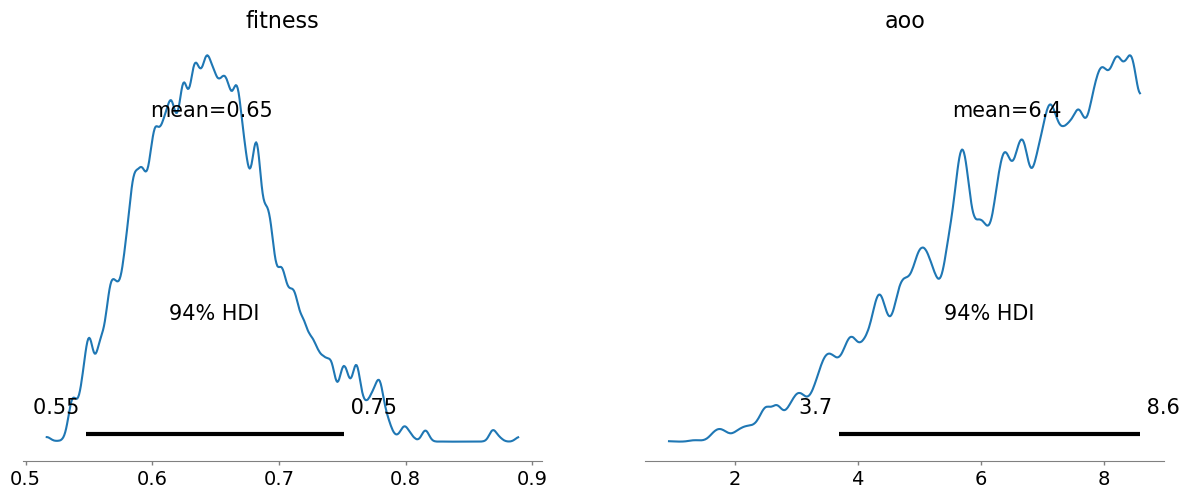

In [8]:
az.plot_posterior(idata)

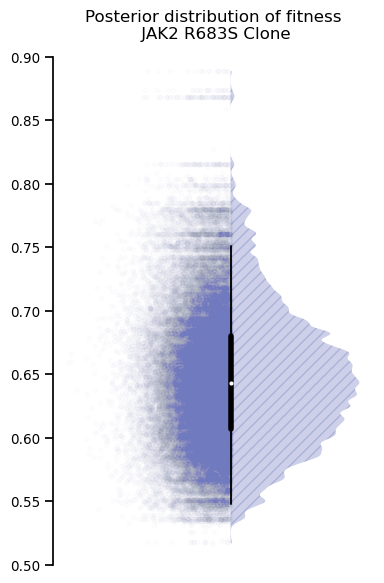

In [9]:
sns.set_context('notebook')
az.plot_violin(
    idata,
    var_names=["fitness"],
    figsize=(4, 6),
    sharey=False,
    sharex=False,
    rug=True,
    #rug_kwargs={"color": "#5d8aa8", 'alpha': 0.005},
    rug_kwargs={"color": ball_pal['JAK2_R683S'], 'alpha': 0.01},
    shade_kwargs={"color": ball_pal['JAK2_R683S'],'hatch':'///'},
)
plt.title("Posterior distribution of fitness\n JAK2 R683S Clone")
sns.despine(trim=True, bottom=True)
plt.tight_layout()
#plt.savefig('fitness-posterior-JAK2R683S_2.png', dpi=300, bbox_inches='tight', transparent=True)

array([<Axes: title={'center': '94.0% HDI'}>,
       <Axes: title={'center': 'ess'}>], dtype=object)

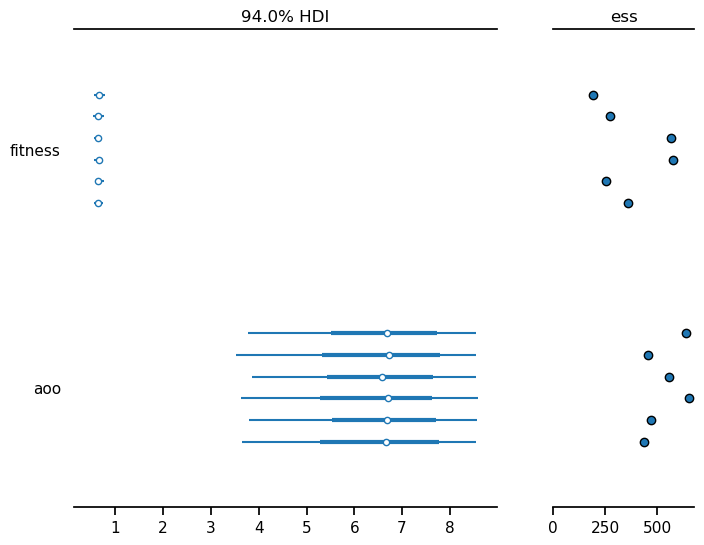

In [10]:
az.plot_forest(idata, ess=True,)

array([[<Axes: >, None],
       [<Axes: xlabel='aoo', ylabel='fitness'>, <Axes: >]], dtype=object)

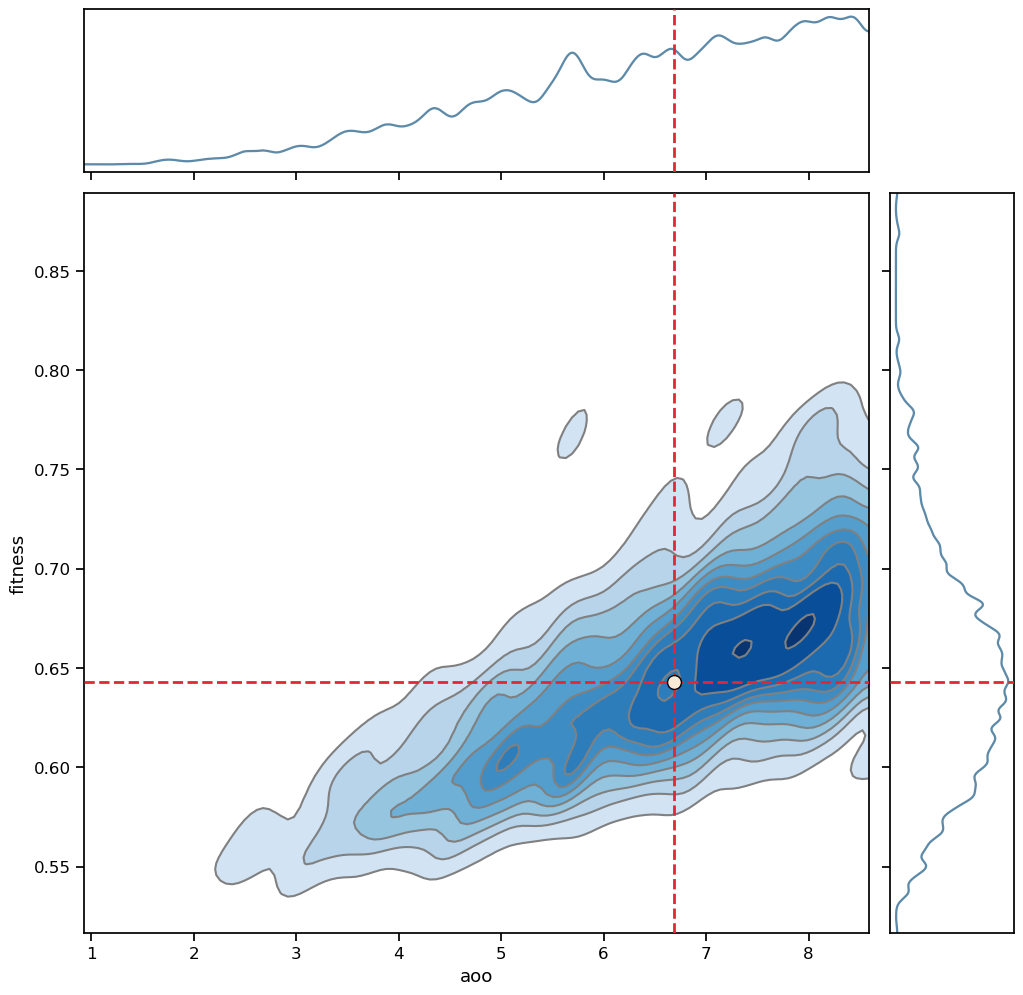

In [11]:
az.plot_pair(
    idata,
    var_names=['aoo', 'fitness', ],
    marginals=True,
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    point_estimate='median',
    point_estimate_kwargs={'color': '#e32636', 'linestyle': '--', 'linewidth': 2, 'zorder': 3},
    point_estimate_marker_kwargs = {'color': '#faebd7', 'zorder': 3, 's': 100, 'marker': 'o', 'alpha': 1, 'edgecolor': 'k'},
    marginal_kwargs={'color': '#5d8aa8',},
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.1)), 'contourf_kwargs': {'cmap': 'Blues', }},    
)


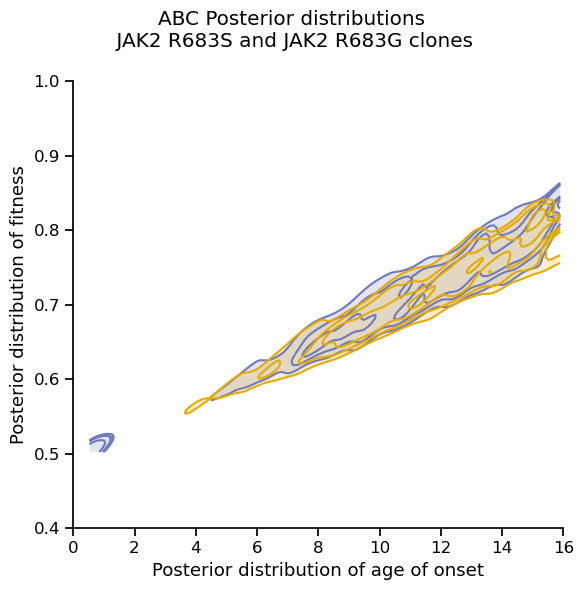

In [12]:
fig, ax = plt.subplots(figsize=(6, 6), sharex=True, sharey=True)
az.plot_pair(
    idata_s,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.49,0.15)), 'contourf_kwargs': {'colors': ball_pal['JAK2_R683S'], 'alpha': 0.2},'contour_kwargs': {'colors': ball_pal['JAK2_R683S'], }},  
    ax=ax,
)
az.plot_pair(
    idata_g,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.49,0.15)), 'contourf_kwargs': {'colors': ball_pal['JAK2_R683G'], 'alpha': 0.2},'contour_kwargs': {'colors': ball_pal['JAK2_R683G'], }},  
    ax=ax,
)
plt.xticks(np.arange(0, 18, 2))
plt.yticks(np.arange(0.4, 1.1, 0.1))
sns.despine(trim=True,)
plt.ylabel('Posterior distribution of fitness')
plt.xlabel('Posterior distribution of age of onset')
plt.suptitle('ABC Posterior distributions\n JAK2 R683S and JAK2 R683G clones')

plt.tight_layout()

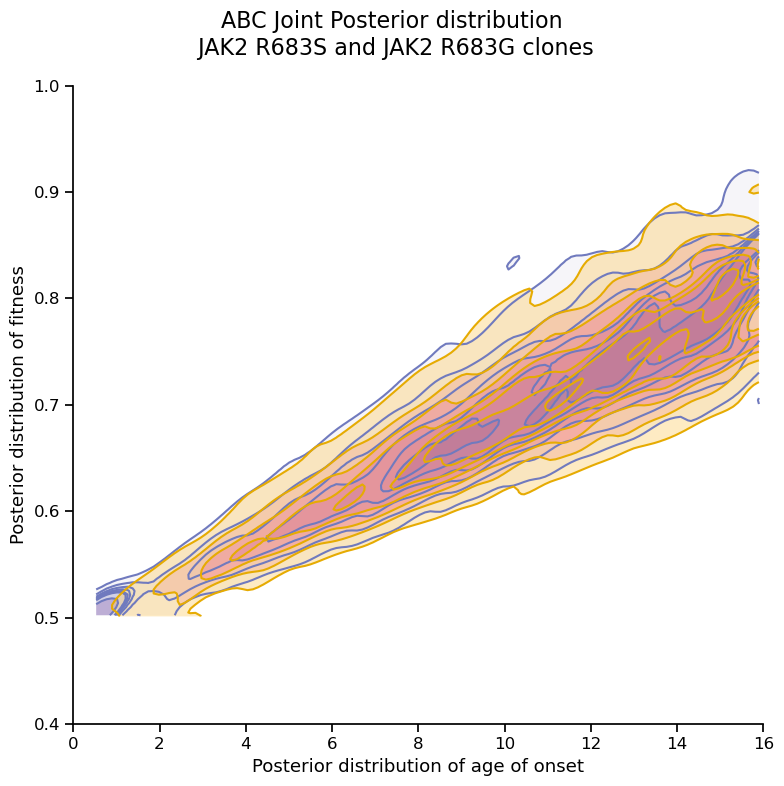

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), sharex=True, sharey=True)
az.plot_pair(
    idata_s,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.15)), 'contourf_kwargs': {'cmap': 'Purples', 'alpha': 0.4},'contour_kwargs': {'colors': ball_pal['JAK2_R683S'], }},  
    ax=ax,
)
az.plot_pair(
    idata_g,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.15)), 'contourf_kwargs': {'cmap': 'YlOrRd', 'alpha': 0.4},'contour_kwargs': {'colors': ball_pal['JAK2_R683G'], }},  
    ax=ax,
)
plt.xticks(np.arange(0, 18, 2))
plt.yticks(np.arange(0.4, 1.1, 0.1))
sns.despine(trim=True,)
plt.ylabel('Posterior distribution of fitness')
plt.xlabel('Posterior distribution of age of onset')
plt.suptitle('ABC Joint Posterior distribution\n JAK2 R683S and JAK2 R683G clones', size=16)
plt.tight_layout()

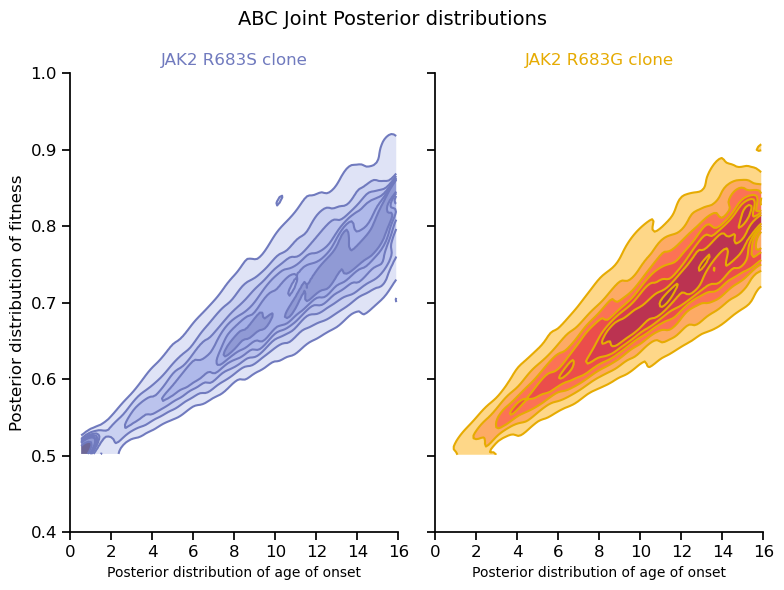

In [14]:
fig, ax = plt.subplots(1,2,figsize=(8, 6), sharex=True, sharey=True)
az.plot_pair(
    idata_s,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.15)), 'contourf_kwargs': {'cmap': palettable.scientific.sequential.Devon_3_r.mpl_colormap, 'alpha': 0.8},'contour_kwargs': {'colors': ball_pal['JAK2_R683S'], }},  
    ax=ax[0],
)
az.plot_pair(
    idata_g,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.15)), 'contourf_kwargs': {'cmap': 'YlOrRd', 'alpha': 0.8},'contour_kwargs': {'colors': ball_pal['JAK2_R683G'], }},  
    ax=ax[1],
)
plt.xticks(np.arange(0, 18, 2))
plt.yticks(np.arange(0.4, 1.1, 0.1))
sns.despine(trim=True,)
ax[0].set_ylabel('Posterior distribution of fitness', fontsize=12)
ax[1].set_ylabel('')
for a in ax:
    a.set_xlabel('Posterior distribution of age of onset',fontsize=10)
ax[0].set_title('JAK2 R683S clone', color=ball_pal['JAK2_R683S'])
ax[1].set_title('JAK2 R683G clone', color=ball_pal['JAK2_R683G'])
plt.xlabel('Posterior distribution of age of onset')
plt.suptitle('ABC Joint Posterior distributions', size=14)
plt.tight_layout()

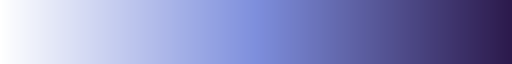

In [15]:
palettable.scientific.sequential.Devon_3_r.mpl_colormap

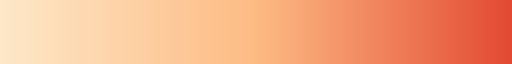

In [16]:
palettable.colorbrewer.sequential.OrRd_3.mpl_colormap

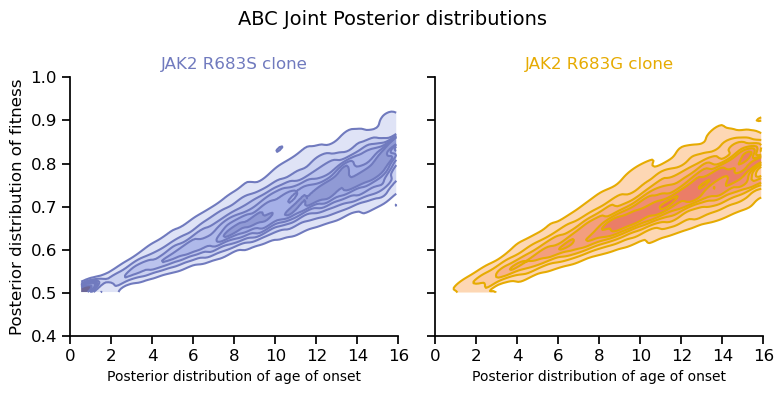

In [22]:
fig, ax = plt.subplots(1,2,figsize=(8, 4), sharex=True, sharey=True)
az.plot_pair(
    idata_s,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.15)), 'contourf_kwargs': {'cmap': palettable.scientific.sequential.Devon_3_r.mpl_colormap, 'alpha': 0.8},'contour_kwargs': {'colors': ball_pal['JAK2_R683S'], }},  
    ax=ax[0],
)
az.plot_pair(
    idata_g,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.15)), 'contourf_kwargs': {'cmap': palettable.colorbrewer.sequential.OrRd_3.mpl_colormap, 'alpha': 0.8},'contour_kwargs': {'colors': ball_pal['JAK2_R683G'], }},  
    ax=ax[1],
)
plt.xticks(np.arange(0, 18, 2))
plt.yticks(np.arange(0.4, 1.1, 0.1))
sns.despine(trim=True,)
ax[0].set_ylabel('Posterior distribution of fitness', fontsize=12)
ax[1].set_ylabel('')
for a in ax:
    a.set_xlabel('Posterior distribution of age of onset',fontsize=10)
ax[0].set_title('JAK2 R683S clone', color=ball_pal['JAK2_R683S'])
ax[1].set_title('JAK2 R683G clone', color=ball_pal['JAK2_R683G'])
plt.xlabel('Posterior distribution of age of onset')
plt.suptitle('ABC Joint Posterior distributions', size=14)
plt.tight_layout()
#plt.savefig('joint-posterior-JAK2R683S_JAK2R683Gt.pdf', dpi=300, bbox_inches='tight', transparent=True)

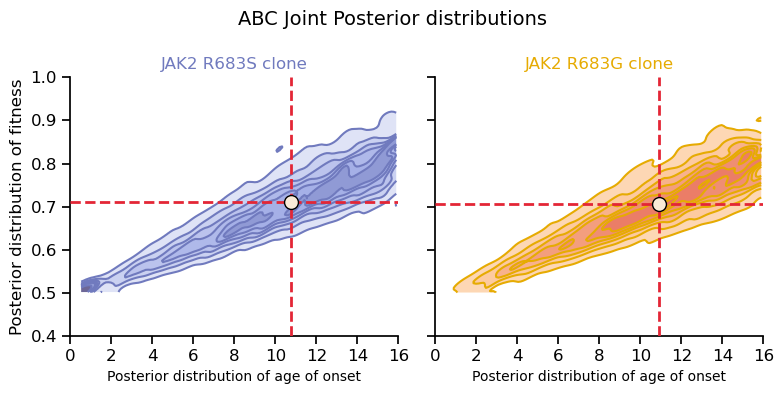

In [23]:
fig, ax = plt.subplots(1,2,figsize=(8, 4), sharex=True, sharey=True)
az.plot_pair(
    idata_s,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    point_estimate='median',
    point_estimate_kwargs={'color': '#e32636', 'linestyle': '--', 'linewidth': 2, 'zorder': 3},
    point_estimate_marker_kwargs = {'color': '#faebd7', 'zorder': 3, 's': 100, 'marker': 'o', 'alpha': 1, 'edgecolor': 'k'},
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.15)), 'contourf_kwargs': {'cmap': palettable.scientific.sequential.Devon_3_r.mpl_colormap, 'alpha': 0.8},'contour_kwargs': {'colors': ball_pal['JAK2_R683S'], }},  
    ax=ax[0],
)
az.plot_pair(
    idata_g,
    var_names=['aoo', 'fitness', ],
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    point_estimate='median',
    point_estimate_kwargs={'color': '#e32636', 'linestyle': '--', 'linewidth': 2, 'zorder': 3},
    point_estimate_marker_kwargs = {'color': '#faebd7', 'zorder': 3, 's': 100, 'marker': 'o', 'alpha': 1, 'edgecolor': 'k'},
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.15)), 'contourf_kwargs': {'cmap': palettable.colorbrewer.sequential.OrRd_3.mpl_colormap, 'alpha': 0.8},'contour_kwargs': {'colors': ball_pal['JAK2_R683G'], }},  
    ax=ax[1],
)
plt.xticks(np.arange(0, 18, 2))
plt.yticks(np.arange(0.4, 1.1, 0.1))
sns.despine(trim=True,)
ax[0].set_ylabel('Posterior distribution of fitness', fontsize=12)
ax[1].set_ylabel('')
for a in ax:
    a.set_xlabel('Posterior distribution of age of onset',fontsize=10)
ax[0].set_title('JAK2 R683S clone', color=ball_pal['JAK2_R683S'])
ax[1].set_title('JAK2 R683G clone', color=ball_pal['JAK2_R683G'])
plt.xlabel('Posterior distribution of age of onset')
plt.suptitle('ABC Joint Posterior distributions', size=14)
plt.tight_layout()
#plt.savefig('joint-posterior-JAK2R683S_JAK2R683G_med_point_est.pdf', dpi=300, bbox_inches='tight', transparent=True)

In [24]:
az.summary(idata_s,  stat_focus="median")#.to_csv('results/4295.JAK2R683S.rec.summary.csv')

In [25]:
az.summary(idata_g,  stat_focus="median")#.to_csv('results/4295.JAK2R683G.rec.summary.csv')

array([<Axes: title={'center': 'fitness'}, xlabel='Total number of draws', ylabel='ESS'>,
       <Axes: title={'center': 'aoo'}, xlabel='Total number of draws', ylabel='ESS'>],
      dtype=object)

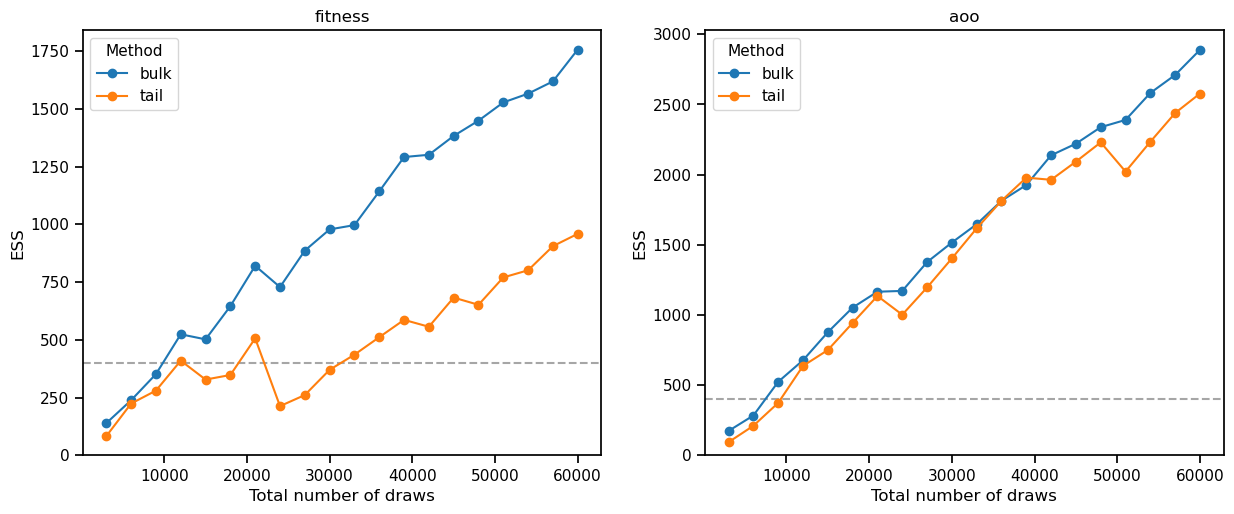

In [20]:
az.plot_ess(idata, kind='evolution')